### Import Library

Bagian ini menjelaskan library utama yang digunakan dalam pipeline **ensemble TCN–BiLSTM** untuk prediksi cuaca. Setiap library memiliki peran spesifik dalam proses mulai dari manajemen file, manipulasi data, pembangunan model, hingga evaluasi dan visualisasi.

#### 1. Sistem File & Metadata
- **`os`** → operasi sistem file (membuat/memeriksa folder, menyusun path, listing file).  
- **`json`** → serialisasi/deserialisasi metadata ke/dari JSON (menyimpan parameter scaler, mapping label, konfigurasi preprocessing).

#### 2. Numerik & Data Tabular
- **`numpy`** → komputasi numerik berbasis array (normalisasi manual, windowing time series, penggabungan probabilitas ensemble).  
- **`pandas`** → manipulasi data tabular (load CSV, cleaning, feature engineering seperti fitur waktu dan turunan).

#### 3. Deep Learning (TensorFlow + Keras)
- **`tensorflow`** → framework utama deep learning (eksekusi tensor, reproducibility, ekspor model ke format SavedModel/H5).  
- **`keras`** → API high-level untuk membangun dan melatih model dengan mudah.  
- **`layers`** → kumpulan layer neural network (Dense, Conv1D, LSTM/Bidirectional, Dropout, BatchNormalization, GlobalAveragePooling1D).

#### 4. Preprocessing & Evaluasi (Scikit-learn)
- **`StandardScaler`** → menstandarkan fitur numerik (mean=0, std=1) agar training stabil.  
- **`LabelEncoder`** → mengubah label kategori menjadi indeks integer konsisten.  
- **`classification_report`** → ringkasan metrik per kelas (precision, recall, F1).  
- **`confusion_matrix`** → matriks kesalahan untuk analisis salah-klasifikasi.  
- **`ConfusionMatrixDisplay`** → visualisasi confusion matrix dengan matplotlib.  
- **`f1_score`** → metrik harmonik precision dan recall, cocok untuk kelas tidak seimbang.  
- **`train_test_split`** → membagi dataset menjadi train/val/test dengan stratifikasi.

#### 5. Visualisasi
- **`matplotlib.pyplot`** → membuat grafik hasil training (akurasi, loss) dan confusion matrix untuk analisis performa model.


In [11]:
import os, json
import numpy as np, pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

### Konfigurasi Awal

Bagian ini berisi variabel konfigurasi utama yang digunakan sepanjang pipeline. Tujuannya adalah memastikan dataset, parameter model, dan reproducibility terkontrol sejak awal sehingga eksperimen konsisten.

#### 1. Dataset & Kolom
- **`CSV_PATH`** → path menuju dataset cuaca Manokwari dalam format CSV. Dataset berisi suhu, kelembapan, tekanan, angin, dan label cuaca.  
- **`TIME_COLUMN`** → nama kolom yang menyimpan informasi waktu (timestamp).  
- **`LOC_COLUMN`** → nama kolom lokasi (kelurahan) pengamatan cuaca.  
- **`TARGET_COLUMN`** → nama kolom target yang akan diprediksi (label cuaca: cerah, berawan, hujan).  

#### 2. Parameter Model
- **`SEQ_LEN = 24`** → panjang urutan input (sequence length). Model menggunakan data 24 jam terakhir untuk memprediksi cuaca jam berikutnya.  
- **`BATCH_SIZE = 64`** → jumlah sampel per batch saat training. Batch besar mempercepat training, tapi membutuhkan memori lebih banyak.  
- **`EPOCHS = 50`** → jumlah iterasi penuh training terhadap dataset. Semakin besar nilainya, semakin lama model belajar, tapi berpotensi meningkatkan akurasi.  

#### 3. Reproducibility
- **`SEED = 42`** → nilai seed untuk random number generator agar hasil training konsisten setiap kali dijalankan.  
- **`np.random.seed(SEED)`** → mengatur seed untuk operasi acak di NumPy (misalnya shuffle data).  
- **`tf.random.set_seed(SEED)`** → mengatur seed untuk operasi acak di TensorFlow (misalnya inisialisasi bobot model).  


In [12]:
CSV_PATH = "../Dataset/Suhu/Prakiraan/dataset_cuaca_manokwari.csv"
TIME_COLUMN = "datetime"
LOC_COLUMN  = "kelurahan"
TARGET_COLUMN = "cuaca"
SEQ_LEN = 24
BATCH_SIZE = 64
EPOCHS = 50
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


### Utility Functions

#### 1. `map_weather_class(label)`
- Memetakan variasi label cuaca BMKG ke tiga kelas utama: **Cerah**, **Berawan**, **Hujan**.
- Menggabungkan label mirip (misalnya *Cerah Berawan* → Berawan, *Hujan Ringan/Sedang/Petir* → Hujan).
- Jika label tidak ada di mapping, fungsi mengembalikan label asli.

#### 2. `add_time_features(df, time_col)`
- Mengubah kolom waktu menjadi fitur numerik: jam, hari dalam minggu, bulan.
- Menambahkan **encoding siklik** (sin/cos) agar pola waktu wrap-around (misalnya jam 23 dekat dengan jam 0).
- Berguna untuk menangkap pola harian, mingguan, dan musiman.

#### 3. `find_first(df, keys)`
- Mencari kolom pertama dalam DataFrame yang mengandung salah satu kata kunci.
- Hanya mengembalikan kolom dengan tipe numerik.
- Dipakai sebagai helper untuk mendeteksi kolom kelembapan, suhu, tekanan, radiasi.

#### 4. `add_berawan_features(df)`
- Menambahkan fitur turunan dari kelembapan, suhu, tekanan, radiasi.
- Fitur berupa **selisih (diff)** 3 jam dan 6 jam untuk menangkap perubahan tren.
- Fitur berupa **rolling standar deviasi** radiasi (3 jam, 6 jam) untuk mengukur variabilitas cahaya/awan.

#### 5. `WIND_DIR_DEG`
- Kamus arah angin kardinal (N, NE, E, dst.) ke derajat kompas (0–360).
- Digunakan untuk konversi arah angin ke representasi numerik.

#### 6. `add_wind_features(df, dir_col, speed_col)`
- Normalisasi teks arah angin (Indonesia → simbol kardinal).
- Konversi arah ke derajat, lalu encoding siklik (sin/cos).
- Jika kecepatan angin tersedia, dihitung komponen vektor **wind_x** dan **wind_y**.

#### 7. `make_windows(data, labels, seq_len, horizon)`
- Membentuk **sliding window** untuk data time series.
- Input: sequence sepanjang `seq_len`, output: label pada posisi `seq_len + horizon - 1`.
- Menghasilkan array fitur (float32) dan label (int32) siap untuk training.

#### 8. `evaluate_preds(y_true, y_pred_num, le, title_prefix)`
- Menampilkan **classification report** (precision, recall, F1 per kelas).
- Menghitung **macro F1** sebagai metrik utama.
- Membuat dan menampilkan **confusion matrix** ternormalisasi dengan matplotlib.


In [13]:
def map_weather_class(label):
    mapping = {
        "Cerah": "Cerah",
        "Berawan": "Berawan",
        "Cerah Berawan": "Berawan",
        "Udara Kabur": "Berawan",
        "Hujan Ringan": "Hujan",
        "Hujan Sedang": "Hujan",
        "Hujan Petir": "Hujan",
        "Petir": "Hujan"
    }
    return mapping.get(label, label)

def add_time_features(df, time_col):
    dt = pd.to_datetime(df[time_col])
    df["hour"] = dt.dt.hour
    df["dayofweek"] = dt.dt.dayofweek
    df["month"] = dt.dt.month
    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
    df["dow_sin"]  = np.sin(2*np.pi*df["dayofweek"]/7)
    df["dow_cos"]  = np.cos(2*np.pi*df["dayofweek"]/7)
    df["mon_sin"]  = np.sin(2*np.pi*df["month"]/12)
    df["mon_cos"]  = np.cos(2*np.pi*df["month"]/12)
    return df

def find_first(df, keys):
    for c in df.columns:
        if any(k in c.lower() for k in keys):
            if pd.api.types.is_numeric_dtype(df[c]):
                return c
    return None

def add_berawan_features(df):
    rh   = find_first(df, ["rh", "humid", "kelembap", "kelembaban"])
    temp = find_first(df, ["suhu", "temp"])
    press= find_first(df, ["tekan", "press"])
    rad  = find_first(df, ["radiasi", "solar", "sun"])
    if rh:
        df["rh_diff3"] = df[rh] - df[rh].shift(3)
        df["rh_diff6"] = df[rh] - df[rh].shift(6)
    if temp:
        df["temp_diff3"] = df[temp] - df[temp].shift(3)
        df["temp_diff6"] = df[temp] - df[temp].shift(6)
    if press:
        df["press_diff3"] = df[press] - df[press].shift(3)
        df["press_diff6"] = df[press] - df[press].shift(6)
    if rad:
        df["rad_std3"] = df[rad].rolling(3, min_periods=1).std()
        df["rad_std6"] = df[rad].rolling(6, min_periods=1).std()
    return df

WIND_DIR_DEG = {
    "N":0, "NNE":22.5, "NE":45, "ENE":67.5,
    "E":90, "ESE":112.5, "SE":135, "SSE":157.5,
    "S":180, "SSW":202.5, "SW":225, "WSW":247.5,
    "W":270, "WNW":292.5, "NW":315, "NNW":337.5
}

def add_wind_features(df, dir_col="arah_angin", speed_col="kecepatan_angin"):
    if dir_col in df.columns:
        d = df[dir_col].astype(str).str.upper().str.strip()
        d = d.replace({
            "TIMUR":"E","BARAT":"W","UTARA":"N","SELATAN":"S",
            "TENGGARA":"SE","BARAT DAYA":"SW","TIMUR LAUT":"NE","BARAT LAUT":"NW"
        }, regex=False)
        deg = d.map(WIND_DIR_DEG)
        fallback_deg = pd.to_numeric(d.str.replace("°","", regex=False), errors="coerce")
        deg = deg.fillna(fallback_deg)
        deg = deg % 360
        df["wind_deg"] = deg
        df["wind_sin"] = np.sin(2*np.pi*df["wind_deg"]/360.0)
        df["wind_cos"] = np.cos(2*np.pi*df["wind_deg"]/360.0)
        if speed_col in df.columns and pd.api.types.is_numeric_dtype(df[speed_col]):
            df["wind_x"] = df[speed_col] * df["wind_cos"]
            df["wind_y"] = df[speed_col] * df["wind_sin"]
    return df

def make_windows(data, labels, seq_len, horizon=1):
    Xs, ys = [], []
    N = len(data)
    for i in range(N - seq_len - horizon + 1):
        Xs.append(data[i:i+seq_len])
        ys.append(labels[i+seq_len+horizon-1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int32)

def evaluate_preds(y_true, y_pred_num, le, title_prefix=""):
    class_names = list(le.classes_)
    labels = list(range(len(class_names)))
    print(f"\n=== Classification Report ({title_prefix}) ===")
    print(classification_report(y_true, y_pred_num,
                                labels=labels,
                                target_names=class_names,
                                digits=3,
                                zero_division=0))
    print("Macro F1:", f1_score(y_true, y_pred_num, labels=labels, average='macro', zero_division=0))
    cm = confusion_matrix(y_true, y_pred_num, labels=labels, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title(f"{title_prefix} Confusion Matrix")
    plt.show()

### Preprocessing Data

Bagian ini menjelaskan langkah-langkah preprocessing dataset cuaca sebelum digunakan untuk training model **ensemble TCN–BiLSTM**.

#### 1. Membaca & Membersihkan Dataset
- **`pd.read_csv(CSV_PATH)`** → membaca dataset cuaca dari file CSV.  
- **`df.columns = [c.strip().lower() for c in df.columns]`** → membersihkan nama kolom (hapus spasi, ubah ke huruf kecil).  
- **`pd.to_datetime(df[TIME_COLUMN])`** → konversi kolom waktu ke tipe datetime.  
- **`sort_values` + `reset_index`** → urutkan data berdasarkan waktu dan reset indeks agar rapi.  

#### 2. Mapping & Encoding Label
- **`map_weather_class`** → memetakan label cuaca ke kategori utama (Cerah, Berawan, Hujan).  
- **`LabelEncoder`** → mengubah label kategori menjadi angka (0,1,2).  
- **`print(le.classes_)`** → menampilkan daftar kelas setelah mapping.  

#### 3. Encoding Lokasi
- Jika kolom lokasi ada:  
  - **`astype(str)`** → ubah ke string.  
  - **`pd.get_dummies`** → one-hot encoding lokasi (prefix `loc`).  
- Jika tidak ada kolom lokasi → buat DataFrame kosong sebagai placeholder.  

#### 4. Feature Engineering
- **`add_time_features`** → menambahkan fitur waktu (jam, hari, bulan + encoding sin/cos).  
- **`add_berawan_features`** → menambahkan fitur turunan kelembapan, suhu, tekanan, radiasi.  
- **`add_wind_features`** → menambahkan fitur arah & kecepatan angin (sin/cos, komponen x/y).  
- **`pd.concat([df, loc_dummies])`** → gabungkan fitur lokasi dengan dataset utama.  

#### 5. Menangani Missing Values
- **`select_dtypes(include=[np.number])`** → ambil semua kolom numerik.  
- **`bfill().ffill()`** → isi nilai kosong dengan backward fill lalu forward fill.  
- Update DataFrame dengan nilai yang sudah terisi.  

#### 6. Normalisasi Fitur
- **`feature_cols`** → daftar semua kolom numerik kecuali target.  
- **`StandardScaler`** → menstandarkan fitur (mean=0, std=1) agar training lebih stabil.  

#### 7. Membuat Window Time Series
- **`make_windows`** → membentuk input sequence sepanjang `SEQ_LEN` (24 jam) dan label horizon 1 jam ke depan.  
- Hasil: **`X_all`** (fitur sekuens) dan **`y_all`** (label).  

#### 8. Membagi Dataset
- **`train_test_split` (pertama)** → membagi data menjadi train (70%) dan sisanya (30%). Stratifikasi menjaga proporsi kelas.  
- **`train_test_split` (kedua)** → membagi sisanya menjadi validation (15%) dan test (15%).  
- Hasil akhir: **`X_train, y_train`**, **`X_val, y_val`**, **`X_test, y_test`**.


In [14]:
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip().lower() for c in df.columns]
df[TIME_COLUMN] = pd.to_datetime(df[TIME_COLUMN])
df = df.sort_values(TIME_COLUMN).reset_index(drop=True)

df[TARGET_COLUMN] = df[TARGET_COLUMN].apply(map_weather_class)
le = LabelEncoder()
df[TARGET_COLUMN] = le.fit_transform(df[TARGET_COLUMN].astype(str))
print("Label classes setelah mapping:", le.classes_)

if LOC_COLUMN in df.columns:
    df[LOC_COLUMN] = df[LOC_COLUMN].astype(str)
    loc_dummies = pd.get_dummies(df[LOC_COLUMN], prefix="loc", drop_first=False)
else:
    loc_dummies = pd.DataFrame(index=df.index)

df = add_time_features(df, TIME_COLUMN)
df = add_berawan_features(df)
df = add_wind_features(df, dir_col="arah_angin", speed_col="kecepatan_angin")
df = pd.concat([df, loc_dummies], axis=1)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_filled = df[num_cols].bfill().ffill()
df[num_cols] = num_filled

feature_cols = [c for c in num_filled.columns if c != TARGET_COLUMN]

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

X_all, y_all = make_windows(
    df[feature_cols].values,
    df[TARGET_COLUMN].values,
    SEQ_LEN, horizon=1
)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.3, stratify=y_all, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED
)


Label classes setelah mapping: ['Berawan' 'Cerah' 'Hujan']


### Build Models

Bagian ini mendefinisikan dua arsitektur model utama yang digunakan dalam ensemble: **BiLSTM** dan **TCN**. Keduanya dirancang untuk menangkap pola temporal pada data cuaca.

#### 1. `build_bilstm(input_shape, n_classes)`
- **Input Layer** → menerima sequence dengan panjang `SEQ_LEN` dan jumlah fitur sesuai `feature_cols`.  
- **Conv1D (16 filters, kernel=3, ReLU)** → ekstraksi pola lokal dari time series.  
- **BatchNormalization** → menstabilkan distribusi aktivasi, mempercepat konvergensi.  
- **Dropout (0.25)** → mencegah overfitting dengan mengacak neuron.  
- **Bidirectional LSTM (32 units, return_sequences=True)** → menangkap dependensi temporal maju dan mundur.  
- **Dropout (0.25)** → regularisasi tambahan.  
- **Bidirectional LSTM (16 units)** → layer LSTM kedua untuk memperdalam representasi temporal.  
- **Dense (32 units, ReLU)** → fully-connected layer untuk abstraksi fitur.  
- **Dense (n_classes, Softmax)** → output probabilitas untuk setiap kelas cuaca.  

#### 2. `build_tcn(input_shape, n_classes)`
- **Input Layer** → menerima sequence dengan panjang `SEQ_LEN` dan jumlah fitur sesuai `feature_cols`.  
- **Conv1D (32 filters, dilation=1, causal, ReLU)** → konvolusi temporal dengan padding kausal (tidak melihat masa depan).  
- **Conv1D (32 filters, dilation=2, causal, ReLU)** → memperluas receptive field dengan dilasi.  
- **Conv1D (32 filters, dilation=4, causal, ReLU)** → menangkap pola jangka panjang.  
- **GlobalAveragePooling1D** → mereduksi dimensi sequence menjadi vektor rata-rata.  
- **Dense (32 units, ReLU)** → fully-connected layer untuk abstraksi fitur.  
- **Dense (n_classes, Softmax)** → output probabilitas untuk setiap kelas cuaca.  

#### 3. Inisialisasi Model
- **`n_classes = len(le.classes_)`** → jumlah kelas target berdasarkan hasil LabelEncoder.  
- **`bilstm_model = build_bilstm(...)`** → membuat model BiLSTM.  
- **`tcn_model = build_tcn(...)`** → membuat model TCN.  

#### 4. Kompilasi Model
- Optimizer: **Adam (learning rate = 5e-4)** → algoritma optimasi adaptif.  
- Loss: **sparse_categorical_crossentropy** → cocok untuk label integer hasil LabelEncoder.  
- Metrics: **accuracy** → metrik utama untuk evaluasi training.  

#### 5. Ringkasan Arsitektur
- **`m.summary()`** → menampilkan struktur layer, jumlah parameter, dan ukuran output untuk setiap model.


In [15]:
def build_bilstm(input_shape, n_classes):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(16, 3, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Bidirectional(layers.LSTM(16))(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inputs, out)

def build_tcn(input_shape, n_classes):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(32, 3, dilation_rate=1, padding="causal", activation="relu")(inputs)
    x = layers.Conv1D(32, 3, dilation_rate=2, padding="causal", activation="relu")(x)
    x = layers.Conv1D(32, 3, dilation_rate=4, padding="causal", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inputs, out)

n_classes = len(le.classes_)
bilstm_model = build_bilstm((SEQ_LEN, len(feature_cols)), n_classes)
tcn_model    = build_tcn((SEQ_LEN, len(feature_cols)), n_classes)

for m in [bilstm_model, tcn_model]:
    m.compile(optimizer=keras.optimizers.Adam(5e-4),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    m.summary()


Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 24, 23)]          0         
                                                                 
 conv1d_4 (Conv1D)           (None, 22, 16)            1120      
                                                                 
 batch_normalization_1 (Bat  (None, 22, 16)            64        
 chNormalization)                                                
                                                                 
 dropout_2 (Dropout)         (None, 22, 16)            0         
                                                                 
 bidirectional_2 (Bidirecti  (None, 22, 64)            12544     
 onal)                                                           
                                                                 
 dropout_3 (Dropout)         (None, 22, 64)            0   

### Training Models

Bagian ini menjalankan proses training untuk kedua arsitektur model (**BiLSTM** dan **TCN**) menggunakan dataset yang sudah diproses.

#### 1. Training BiLSTM
- **`bilstm_model.fit(...)`** → melatih model BiLSTM dengan data training.  
- **Input**: `X_train, y_train`.  
- **Validation**: `(X_val, y_val)` digunakan untuk memantau performa model selama training.  
- **Parameter**:
  - `epochs = EPOCHS` → jumlah iterasi penuh training (50).  
  - `batch_size = BATCH_SIZE` → jumlah sampel per batch (64).  
  - `verbose = 1` → menampilkan progress training di console.  
- **Output**: `history_bilstm` menyimpan log training (loss, accuracy, val_loss, val_accuracy per epoch).

#### 2. Training TCN
- **`tcn_model.fit(...)`** → melatih model TCN dengan data training.  
- **Input**: `X_train, y_train`.  
- **Validation**: `(X_val, y_val)` digunakan untuk evaluasi selama training.  
- **Parameter**:
  - `epochs = EPOCHS` → jumlah iterasi penuh training (50).  
  - `batch_size = BATCH_SIZE` → jumlah sampel per batch (64).  
  - `verbose = 1` → menampilkan progress training di console.  
- **Output**: `history_tcn` menyimpan log training (loss, accuracy, val_loss, val_accuracy per epoch).

#### 3. Catatan
- **History objek** (`history_bilstm`, `history_tcn`) dapat digunakan untuk:
  - Membuat grafik kurva **loss** dan **accuracy** per epoch.  
  - Membandingkan performa BiLSTM vs TCN pada data validasi.  
  - Menentukan apakah model mengalami **overfitting** atau **underfitting**.


In [6]:
history_bilstm = bilstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

history_tcn = tcn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/50


157/157 [==============================] - 18s 42ms/step - loss: 0.6885 - accuracy: 0.7174 - val_loss: 0.5085 - val_accuracy: 0.7985
Epoch 2/50
157/157 [==============================] - 3s 21ms/step - loss: 0.4685 - accuracy: 0.8110 - val_loss: 0.4320 - val_accuracy: 0.8297
Epoch 3/50
157/157 [==============================] - 4s 25ms/step - loss: 0.4164 - accuracy: 0.8327 - val_loss: 0.3913 - val_accuracy: 0.8478
Epoch 4/50
157/157 [==============================] - 4s 23ms/step - loss: 0.3880 - accuracy: 0.8457 - val_loss: 0.3716 - val_accuracy: 0.8627
Epoch 5/50
157/157 [==============================] - 4s 23ms/step - loss: 0.3666 - accuracy: 0.8559 - val_loss: 0.3620 - val_accuracy: 0.8613
Epoch 6/50
157/157 [==============================] - 4s 24ms/step - loss: 0.3409 - accuracy: 0.8598 - val_loss: 0.3416 - val_accuracy: 0.8688
Epoch 7/50
157/157 [==============================] - 4s 23ms/step - loss: 0.3266 - accuracy: 0.8688 - val_loss: 0.3348 - val_accuracy: 0.8

### Ensemble Prediction

Bagian ini menjelaskan proses **ensemble** menggunakan metode *soft voting* antara model **BiLSTM** dan **TCN**.

#### 1. Prediksi Probabilitas
- **`bilstm_model.predict(X_test, verbose=0)`** → menghasilkan probabilitas prediksi dari model BiLSTM untuk setiap kelas cuaca pada data uji.  
- **`tcn_model.predict(X_test, verbose=0)`** → menghasilkan probabilitas prediksi dari model TCN untuk setiap kelas cuaca pada data uji.  
- Output kedua model berupa array probabilitas dengan dimensi `[jumlah_sample, n_classes]`.

#### 2. Soft Voting Ensemble
- **`probs_ensemble = (probs_bilstm + probs_tcn) / 2.0`**  
  - Menggabungkan probabilitas dari kedua model dengan cara rata-rata.  
  - Disebut *soft voting* karena ensemble dilakukan pada level probabilitas, bukan label akhir.  
  - Tujuannya: memanfaatkan kekuatan masing-masing model dan mengurangi bias prediksi tunggal.  

#### 3. Prediksi Final
- **`preds_ensemble = np.argmax(probs_ensemble, axis=1)`**  
  - Mengambil indeks kelas dengan probabilitas tertinggi dari hasil ensemble.  
  - Hasil akhir berupa array label prediksi untuk setiap sampel pada data uji.  

#### 4. Catatan
- Soft voting lebih stabil dibanding *hard voting* karena mempertimbangkan distribusi probabilitas antar kelas.  
- Ensemble ini diharapkan meningkatkan akurasi dan F1-score dibandingkan model tunggal (BiLSTM atau TCN saja).


In [7]:
probs_bilstm = bilstm_model.predict(X_test, verbose=0)
probs_tcn    = tcn_model.predict(X_test, verbose=0)

# Soft voting ensemble
probs_ensemble = (probs_bilstm + probs_tcn) / 2.0
preds_ensemble = np.argmax(probs_ensemble, axis=1)

### Evaluasi Ensemble BiLSTM + TCN (H+1)

Bagian ini menggunakan fungsi **`evaluate_preds`** untuk menilai performa hasil prediksi ensemble pada data uji.

#### 1. Input
- **`y_test`** → label sebenarnya dari data uji.  
- **`preds_ensemble`** → label prediksi hasil *soft voting* ensemble BiLSTM + TCN.  
- **`le`** → objek `LabelEncoder` yang menyimpan mapping kelas (misalnya: Cerah, Berawan, Hujan).  
- **`title_prefix="Ensemble BiLSTM+TCN (H+1)"`** → judul yang ditampilkan pada laporan dan confusion matrix.  

#### 2. Output
- **Classification Report**  
  - Precision, recall, dan F1-score untuk setiap kelas cuaca.  
  - Macro/weighted average untuk evaluasi keseluruhan.  
- **Macro F1 Score**  
  - Rata-rata F1 antar kelas tanpa bobot, cocok untuk dataset dengan distribusi kelas tidak seimbang.  
- **Confusion Matrix (normalized)**  
  - Menampilkan proporsi prediksi benar/salah per kelas aktual.  
  - Visualisasi menggunakan `ConfusionMatrixDisplay` dengan colormap biru.  
  - Judul grafik: *"Ensemble BiLSTM+TCN (H+1) Confusion Matrix"*.  

#### 3. Catatan
- Evaluasi ini memberikan gambaran apakah ensemble meningkatkan performa dibanding model tunggal.  
- Fokus utama ada pada **macro F1** karena lebih adil untuk semua kelas, bukan hanya kelas mayoritas.  
- Confusion matrix membantu mengidentifikasi pola kesalahan (misalnya kelas hujan sering diprediksi berawan).



=== Classification Report (Ensemble BiLSTM+TCN (H+1)) ===
              precision    recall  f1-score   support

     Berawan      0.921     0.924     0.922      1193
       Cerah      0.893     0.938     0.915       614
       Hujan      0.879     0.789     0.832       342

    accuracy                          0.906      2149
   macro avg      0.898     0.884     0.890      2149
weighted avg      0.906     0.906     0.906      2149

Macro F1: 0.8897456510202614


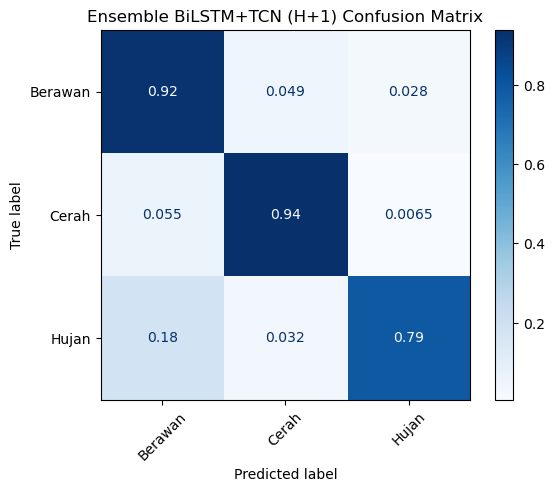

In [8]:
evaluate_preds(y_test, preds_ensemble, le, title_prefix="Ensemble BiLSTM+TCN (H+1)")


### Menyimpan Model & Metadata

Bagian ini menyimpan hasil training model dan metadata penting agar pipeline bisa digunakan kembali untuk inference atau deployment.

#### 1. Menyimpan Model
- **`bilstm_model.save("../Result Model/model_bilstm_h1.h5")`**  
  - Menyimpan model BiLSTM dalam format HDF5 (`.h5`).  
  - File ini berisi arsitektur, bobot, dan konfigurasi model.  

- **`tcn_model.save("../Result Model/model_tcn_h1.h5")`**  
  - Menyimpan model TCN dalam format HDF5 (`.h5`).  
  - File ini juga dapat langsung di-load kembali untuk evaluasi atau prediksi.  

#### 2. Metadata Forecast
- **`feature_cols`** → daftar fitur numerik yang digunakan dalam training.  
- **`scaler_mean`** → nilai rata-rata dari setiap fitur setelah normalisasi (StandardScaler).  
- **`scaler_scale`** → nilai standar deviasi dari setiap fitur setelah normalisasi.  
- **`labels`** → mapping indeks integer ke nama kelas cuaca (misalnya 0: Cerah, 1: Berawan, 2: Hujan).  
- **`wind_dir_mapping`** → kamus arah angin kardinal ke derajat kompas (0–360).  

#### 3. Menyimpan Metadata ke JSON
- **`forecast_meta.json`** → file JSON yang berisi konfigurasi preprocessing dan informasi label.  
- Disimpan dengan format rapi (`indent=2`) dan mendukung karakter non-ASCII (`ensure_ascii=False`).  

#### 4. Output
- **`print("Model BiLSTM, TCN, metadata, dan evaluasi ensemble berhasil dibuat.")`**  
  - Pesan konfirmasi bahwa model, metadata, dan evaluasi ensemble sudah berhasil dibuat dan disimpan.  


In [9]:
bilstm_model.save(r"../Result Model/model_bilstm_h1.h5")
tcn_model.save(r"../Result Model/model_tcn_h1.h5")

meta = {
    "feature_cols": feature_cols,
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "labels": {i: label for i, label in enumerate(le.classes_)},
    "wind_dir_mapping": WIND_DIR_DEG
}
with open(r"../Result Model/forecast_meta.json", "w") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Model BiLSTM, TCN, metadata, dan evaluasi ensemble berhasil dibuat.")


Model BiLSTM, TCN, metadata, dan evaluasi ensemble berhasil dibuat.


c:\Users\ASUS\anaconda3\envs\ml-env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### Ensemble Model (BiLSTM + TCN)

Bagian ini membangun model **ensemble** dengan menggabungkan output dari BiLSTM dan TCN menggunakan pendekatan *soft voting* berbobot rata-rata.

#### 1. Input
- **`Input(shape=(SEQ_LEN, len(feature_cols)), name="ts_input")`**  
  - Layer input untuk data time series dengan panjang sequence `SEQ_LEN` dan jumlah fitur sesuai `feature_cols`.  
  - Nama input: `"ts_input"`.

#### 2. Output dari Model Individu
- **`out_bilstm = bilstm_model(inp)`** → output probabilitas dari model BiLSTM.  
- **`out_tcn = tcn_model(inp)`** → output probabilitas dari model TCN.  

#### 3. Bobot Ensemble
- **`w_b = tf.constant(0.5)`** → bobot untuk BiLSTM.  
- **`w_t = tf.constant(0.5)`** → bobot untuk TCN.  
- Bobot sama besar (0.5, 0.5) → ensemble rata-rata.

#### 4. Kombinasi Linear
- **`Add(name="ensemble_add")([...])`** → menjumlahkan output BiLSTM dan TCN setelah dikalikan bobot masing-masing.  
- Menggunakan **`Lambda`** untuk operasi perkalian bobot.  

#### 5. Normalisasi Probabilitas
- **`Lambda(..., name="ensemble_norm")`** → membagi hasil kombinasi dengan jumlah probabilitas agar tetap valid (total = 1).  
- **`tf.clip_by_value`** → mencegah pembagian dengan nol (nilai minimum 1e-9).  

#### 6. Bangun Model Ensemble
- **`ensemble_model = keras.Model(...)`** → membuat model Keras dengan input `inp` dan output `ens_out`.  
- Nama model: `"ensemble_bilstm_tcn_h1"`.  

#### 7. Simpan Model
- **`ensemble_model.save("../Result Model/model_ensemble_h1.h5")`** → menyimpan model ensemble ke file `.h5`.  
- **`print(...)`** → menampilkan pesan konfirmasi bahwa model ensemble berhasil disimpan.  

#### 8. Catatan
- Ensemble ini menggabungkan kekuatan BiLSTM (dependensi temporal) dan TCN (pola jangka panjang dengan dilasi).  
- Dengan soft voting berbobot rata-rata, hasil prediksi lebih stabil dibandingkan model tunggal.


In [10]:
from tensorflow.keras.layers import Input, Lambda, Add

# Input sama dengan forecasting (time series)
inp = Input(shape=(SEQ_LEN, len(feature_cols)), name="ts_input")

# Output dari masing-masing model
out_bilstm = bilstm_model(inp)
out_tcn    = tcn_model(inp)

# Bobot ensemble (soft voting rata-rata)
w_b = tf.constant(0.5, dtype=tf.float32)
w_t = tf.constant(0.5, dtype=tf.float32)

# Kombinasi linear
ens_out = Add(name="ensemble_add")([
    Lambda(lambda x: x * w_b)(out_bilstm),
    Lambda(lambda x: x * w_t)(out_tcn)
])

# Normalisasi supaya tetap distribusi probabilitas
ens_out = Lambda(lambda x: x / tf.clip_by_value(tf.reduce_sum(x, axis=-1, keepdims=True),
                                               1e-9, np.inf),
                 name="ensemble_norm")(ens_out)

# Bangun model ensemble
ensemble_model = keras.Model(inputs=inp, outputs=ens_out, name="ensemble_bilstm_tcn_h1")

# Simpan ke file .h5
ensemble_model.save(r"../Result Model/model_ensemble_h1.h5")
print("Ensemble forecasting model saved to: ../Result Model/model_ensemble_h1.h5")


Ensemble forecasting model saved to: ../Result Model/model_ensemble_h1.h5
